# Flow matching on Mnist dataset

In [2]:
import torch
from torch import nn, Tensor
from torch.nn import functional as F    
import torchvision 
from torchvision.datasets import MNIST
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import tqdm
from tqdm import tqdm
import time
import os
import sys
import datetime
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
batch_size = 32
num = 2
train_dataset = MNIST(root='./data', train=True, transform=torchvision.transforms.ToTensor(), download=True)
filtered_data = [(x, y) for x, y in train_dataset if y == num]
test_dataset = MNIST(root='./data', train=False, transform=torchvision.transforms.ToTensor(), download=True)
train_loader = DataLoader(dataset= filtered_data, batch_size= batch_size, shuffle=True)
test_loader = DataLoader(dataset= test_dataset, batch_size= batch_size, shuffle=False)

In [4]:
class Flow(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(2, 64, 3, padding=1), nn.BatchNorm2d(64),nn.ReLU(), 
                                  nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(64, 128, 3, padding=1),nn.BatchNorm2d(128), nn.ReLU(), 
                                  nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.enc3 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256),nn.ReLU(), 
                                  nn.Conv2d(256, 256, 3, padding=1), nn.ReLU())
        
        self.dec3 = nn.Sequential(nn.Conv2d(256, 256, 3, padding=1), 
                                  nn.ReLU(), nn.Conv2d(256, 128, 3, padding=1), nn.ReLU())
        self.dec2 = nn.Sequential(nn.Conv2d(256, 128, 3, padding=1), 
                                  nn.ReLU(), nn.Conv2d(128, 64, 3, padding=1), nn.ReLU())
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1),  
                                  nn.Conv2d(64, 1, 3, padding=1))
        self.time_emb1 = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), 
                                      nn.Linear(32, 64), nn.ReLU(),
                                      nn.Linear(64, 64))
        self.time_emb2 = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), 
                                      nn.Linear(32, 128), nn.ReLU(), 
                                      nn.Linear(128, 128))        
        self.time_emb3 = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), 
                                      nn.Linear(32, 128), nn.ReLU(),
                                      nn.Linear(128, 256),nn.ReLU(),
                                      nn.Linear(256, 256))
        

        
    def forward(self, x, t):
        t_emb1 = self.time_emb3(t.view(-1, 1)).view(-1, 256, 1, 1)
        t_emb2 = self.time_emb2(t.view(-1, 1)).view(-1, 128, 1, 1)
        t_emb3 = self.time_emb1(t.view(-1, 1)).view(-1, 64, 1, 1)
        x = torch.cat([x, t.view(-1, 1, 1, 1).expand(-1, 1, 28, 28)], dim=1)
        e1 = self.enc1(x) 
        e2 = self.enc2(e1) 
        e3 = self.enc3(e2) + t_emb1
        d3 = self.dec3(e3) + t_emb2
        d3 = nn.functional.interpolate(d3, scale_factor=2, mode='bilinear')
        d2 = self.dec2(torch.cat([d3, e2], dim=1)) + t_emb3
        d2 = nn.functional.interpolate(d2, scale_factor=2, mode='bilinear')
        d1 = self.dec1(torch.cat([d2, e1], dim=1)) 
        return d1


    

In [8]:
from torchinfo import summary

model = Flow().to(device)
summary(model, input_size=[(batch_size, 1, 28, 28), (batch_size, 1)])

Layer (type:depth-idx)                   Output Shape              Param #
Flow                                     [32, 1, 28, 28]           --
├─Sequential: 1-1                        [32, 256]                 --
│    └─Linear: 2-1                       [32, 32]                  64
│    └─ReLU: 2-2                         [32, 32]                  --
│    └─Linear: 2-3                       [32, 128]                 4,224
│    └─ReLU: 2-4                         [32, 128]                 --
│    └─Linear: 2-5                       [32, 256]                 33,024
│    └─ReLU: 2-6                         [32, 256]                 --
│    └─Linear: 2-7                       [32, 256]                 65,792
├─Sequential: 1-2                        [32, 128]                 --
│    └─Linear: 2-8                       [32, 32]                  64
│    └─ReLU: 2-9                         [32, 32]                  --
│    └─Linear: 2-10                      [32, 128]                 4,224
│

In [5]:
a = 1
b = 1
sigma_m = 1e-8

In [17]:
def c(t):
    ct = -2*t
    return torch.Tensor(ct)
def psi(x: Tensor,z: Tensor,t: Tensor):
    t_square = t**2
    return a*t_square.view(-1,1,1,1) + (z - a)*t.view(-1,1,1,1) + (b*t_square.view(-1,1,1,1) + (sigma_m - 1 - b)*t.view(-1,1,1,1) + 1)*x
def u_psi(x:Tensor, z: Tensor, t: Tensor):
    first_term = 2*(a + b*x)
    second_term = c(t).view(-1,1,1,1)*(2*a*t.view(-1,1,1,1) +(z-a) + (2*b*t.view(-1,1,1,1) + sigma_m - 1 - b)*x)
    return first_term - second_term
def F(r :Tensor,t: Tensor):
    x = r[:,0]
    y = r[:,1]
    upper = y
    lower = model(x,t) + c(t).view(-1,1,1,1)*y
    return torch.stack([upper, lower], dim=1)

In [18]:
# training
num_epochs = 5
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.2)
loss_fn = nn.MSELoss()
best_loss = float('inf')
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
    for images, _ in pbar:
        images = images.to(device)
        noise = torch.randn_like(images).to(device)

        t = torch.rand(images.size(0), 1).to(device)
        x_t = psi(noise, images, t)
        u_true = u_psi(noise, images, t)
        outputs = model(x_t, t)
        loss = loss_fn(outputs, u_true)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{optimizer.param_groups[0]["lr"]:.6f}'})
    epoch_loss = running_loss / len(train_loader)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), 'models/best_model.pth')
        print(f"Saved best model (loss: {best_loss:.4f})")
    scheduler.step()
model.load_state_dict(torch.load('models/best_model.pth'))


Epoch 0: 100%|██████████| 187/187 [00:03<00:00, 50.29it/s, loss=0.3445, lr=0.000100]


Saved best model (loss: 0.7178)


Epoch 1: 100%|██████████| 187/187 [00:03<00:00, 54.65it/s, loss=0.4392, lr=0.000100]


Saved best model (loss: 0.5074)


Epoch 2: 100%|██████████| 187/187 [00:03<00:00, 54.77it/s, loss=0.2457, lr=0.000100]


Saved best model (loss: 0.4794)


Epoch 3: 100%|██████████| 187/187 [00:03<00:00, 54.56it/s, loss=1.2223, lr=0.000100]


Saved best model (loss: 0.4566)


Epoch 4: 100%|██████████| 187/187 [00:03<00:00, 53.86it/s, loss=0.4482, lr=0.000100]


<All keys matched successfully>

In [45]:
torch.save(model.state_dict(), f"models/model_2_order{num}_loss_{best_loss}.pth")

In [34]:
#model = Flow().to(device)
#model.load_state_dict(torch.load(f"model_1.pth"))


In [19]:
# Generate samples
import numpy as np
steps = 100
print("\nGenerating samples...")
model.eval()
with torch.no_grad():
    x_0 = torch.randn(16, 1, 28, 28, device=device)
    xp_0 = torch.zeros_like(x_0)
    
    T = np.linspace(0, 1, steps)
    x_t = x_0    
    xp_t = xp_0
    for step in range(steps-1):
        t_start = torch.tensor(T[step], dtype=torch.float32).expand(16).to(device)
        t_end = torch.tensor(T[step+1], dtype=torch.float32).expand(16).to(device)
        delta_t = t_end - t_start
        r_t = torch.stack([x_t, xp_t], dim=1)

        k1 = delta_t.view(-1,1,1,1,1)*F(r_t,t_start)
        r_mid = r_t + 1/2*k1
        k2 = delta_t.view(-1,1,1,1,1)*F(r_mid, t_start + delta_t/2)
        r_t = r_t + k2
        x_t = r_t[:,0]
        xp_t =r_t[:,1]
    
    samples = x_t.cpu()


Generating samples...


In [53]:
len(train_dataset)

60000

Train data


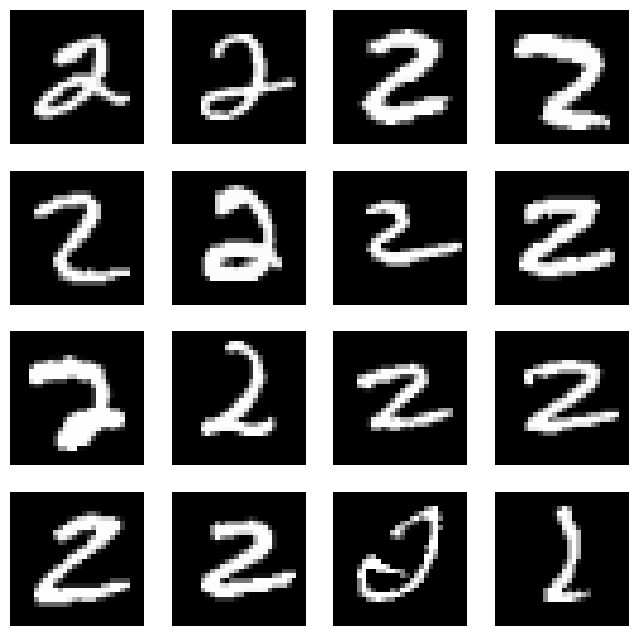

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
image_init = filtered_data[:16]
for i, ax in enumerate(axes.flat):
    ax.imshow(image_init[i][0].squeeze().cpu(), cmap='gray')
    ax.axis('off')
print("Train data")
plt.show()

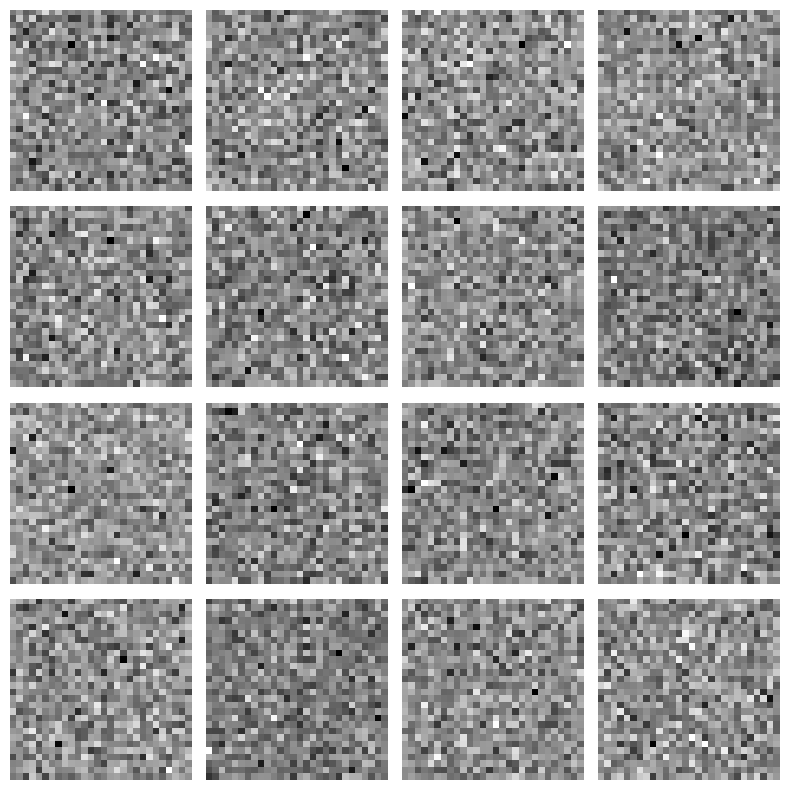

In [20]:
# Display
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i, 0], cmap='gray')
    ax.axis('off')
plt.tight_layout()
#plt.savefig('flow_matching_samples.png')
#print("Samples saved to flow_matching_samples.png")
plt.show()

In [39]:
def F(r: Tensor, t: Tensor):
    x = r[:, 0]   # [B, 1, 28, 28]
    y = r[:, 1]   # [B, 1, 28, 28]
    
    dx_dt = y
    dy_dt = model(x, t) + c(t).view(-1, 1, 1, 1) * y
    
    return torch.stack([dx_dt, dy_dt], dim=1)  # [B, 2, 1, 28, 28]

# Sampling loop
T = np.linspace(0, 1, steps)
r_t = torch.stack([x_0, xp_0], dim=1)  # [B, 2, 1, 28, 28]

for step in range(steps - 1):
    t_curr = torch.tensor(T[step], dtype=torch.float32).expand(16).to(device)
    t_next = torch.tensor(T[step + 1], dtype=torch.float32).expand(16).to(device)
    dt = (t_next - t_curr).view(-1, 1, 1, 1, 1)
    
    k1 = F(r_t, t_curr)
    r_mid = r_t + 0.5 * dt * k1
    t_mid = (t_curr + t_next) / 2
    k2 = F(r_mid, t_mid)
    
    r_t = r_t + dt * k2

samples = r_t[:, 0].cpu().detach().numpy()  # Extract x component

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 12.34 GiB is allocated by PyTorch, and 344.82 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [25]:
samples = samples.detach().numpy()

In [26]:
samples

array([[[[ 0.86303645,  2.4403634 ,  0.7047157 , ...,  1.2622244 ,
           1.0079161 ,  1.2049541 ],
         [ 0.7675943 ,  0.63065255,  1.1986873 , ...,  0.8786514 ,
           0.40749964,  1.1927029 ],
         [ 0.9075873 ,  1.3935632 ,  1.5410082 , ...,  0.45582193,
           0.8117289 ,  1.9040408 ],
         ...,
         [ 1.1901166 ,  1.4348898 ,  1.6447186 , ...,  1.1355006 ,
           0.8927734 ,  0.92525333],
         [ 0.94839466,  1.0367341 ,  1.1324437 , ...,  1.2940422 ,
           1.1999931 ,  1.4630159 ],
         [ 1.5459253 ,  0.49387544,  1.2729815 , ...,  1.128067  ,
           1.1453854 ,  0.39504147]]],


       [[[ 1.8464578 ,  0.8729005 ,  1.0048468 , ...,  1.1653932 ,
           1.5253786 ,  2.4109168 ],
         [ 0.8991551 ,  1.3428426 ,  1.8214943 , ...,  0.34753063,
           1.6273249 ,  0.91011673],
         [ 0.7438856 ,  0.43154413,  1.1946713 , ...,  2.0965548 ,
           0.88327813,  1.4150203 ],
         ...,
         [ 1.6150432 ,  1.052205